# Water Council basin input, 2025–2026

This notebook replaces observed river discharge with one annual-cycle input: modeled water arriving from **rain + delayed snowmelt + a small humidity/dew estimate**. It preserves the installation contract of exactly **720 samples per stage** from July 1, 2025 through June 30, 2026.

The raw records are NOAA/NCEI Daily Summaries. Snowfall is stored and later released as melt, so frozen precipitation is not counted twice. The seven station choices, query URL, gap handling, conceptual Delta weights, and limitations are documented in `README.md`.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

HERE = Path.cwd()
if not (HERE / 'build_basin_input_720.py').exists():
    HERE = Path('flow/data/basin_input').resolve()
sys.path.insert(0, str(HERE))

from build_basin_input_720 import (
    DELTA_WEIGHTS, STATIONS, TARGET_SAMPLE_COUNT, build_all,
)

daily, sampled = build_all(write_outputs=False)
print(f'{len(daily):,} daily stage rows; {len(sampled):,} sampled stage rows')

2,555 daily stage rows; 5,040 sampled stage rows


## Coverage and annual components

`observed_days` reports station rows present in the NOAA response. Multiday precipitation reports are distributed across their stated interval; remaining missing precipitation is zero-filled. `snowmelt_mm` is capped by the modeled snow store.

In [2]:
coverage = (
    daily.groupby(['stage_id', 'station_id', 'station_name'], sort=False)
    .agg(
        observed_days=('observed', 'sum'),
        precipitation_mm=('precip_mm', 'sum'),
        rainfall_mm=('rain_input_mm', 'sum'),
        snow_stored_mm=('snow_storage_input_mm', 'sum'),
        snowmelt_mm=('snowmelt_input_mm', 'sum'),
        humidity_mm=('humidity_input_mm', 'sum'),
        peak_norm=('norm', 'max'),
    )
    .round(2)
)
coverage

,,,observed_days,precipitation_mm,rainfall_mm,snow_stored_mm,snowmelt_mm,humidity_mm,peak_norm
stage_id,station_id,station_name,,,,,,,
shasta,USC00045983,"MOUNT SHASTA, CA US",365,967.9,855.6,112.3,112.3,1.11,1.00
mccloud,USC00045449,"MCCLOUD, CA US",306,1330.4,1284.7,45.7,45.7,0.85,1.00
cottonwood,USW00024216,"RED BLUFF MUNICIPAL AIRPORT, CA US",365,623.0,623.0,0.0,0.0,2.28,1.00
mill_creek,USC00045679,"MINERAL, CA US",260,1405.9,996.1,409.8,409.8,0.80,1.00
feather,USC00047195,"QUINCY, CA US",360,1062.3,1001.0,61.3,61.3,0.38,1.00
american,USW00023225,"BLUE CANYON NYACK AIRPORT, CA US",364,1826.5,1596.9,229.6,229.6,2.23,1.00
delta,USW00023237,"STOCKTON AIRPORT, CA US",365,386.0,386.0,0.0,0.0,1.50,0.97


## Daily normalized local-water arrival

The Delta line is the weighted seven-stage aggregate used by the final screen. The weights are conceptual rather than calibrated basin areas:

In [3]:
pd.Series(DELTA_WEIGHTS, name='Delta conceptual weight').to_frame().T

,shasta,mccloud,cottonwood,mill_creek,feather,american,delta
Delta conceptual weight,0.24,0.18,0.1,0.06,0.23,0.14,0.05


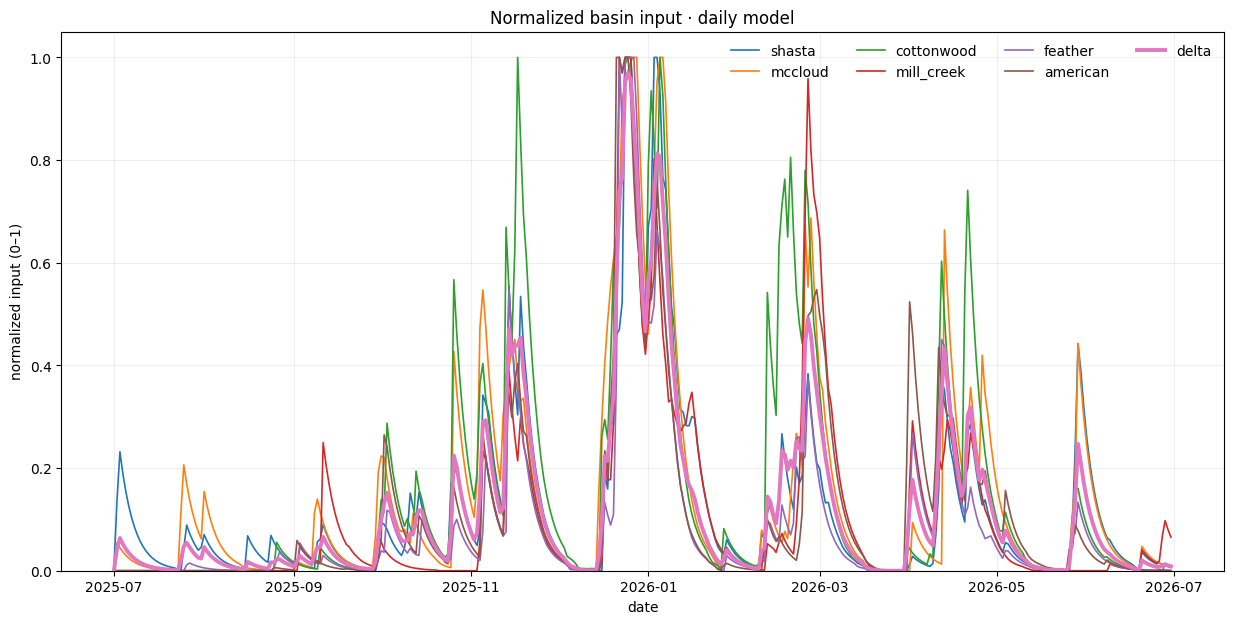

In [4]:
fig, ax = plt.subplots(figsize=(15, 7))
for stage_id, group in daily.groupby('stage_id', sort=False):
    width = 2.8 if stage_id == 'delta' else 1.2
    ax.plot(group['date'], group['norm'], label=stage_id, linewidth=width)
ax.set(title='Normalized basin input · daily model', ylabel='normalized input (0–1)', xlabel='date')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.2)
ax.legend(ncol=4, frameon=False)
plt.show()

## Godot-ready 720-sample series

Linear interpolation maps the 365 daily values to 720 uniformly spaced samples. Godot interpolates once more between adjacent rows during playback, including the June 30 → July 1 wrap.

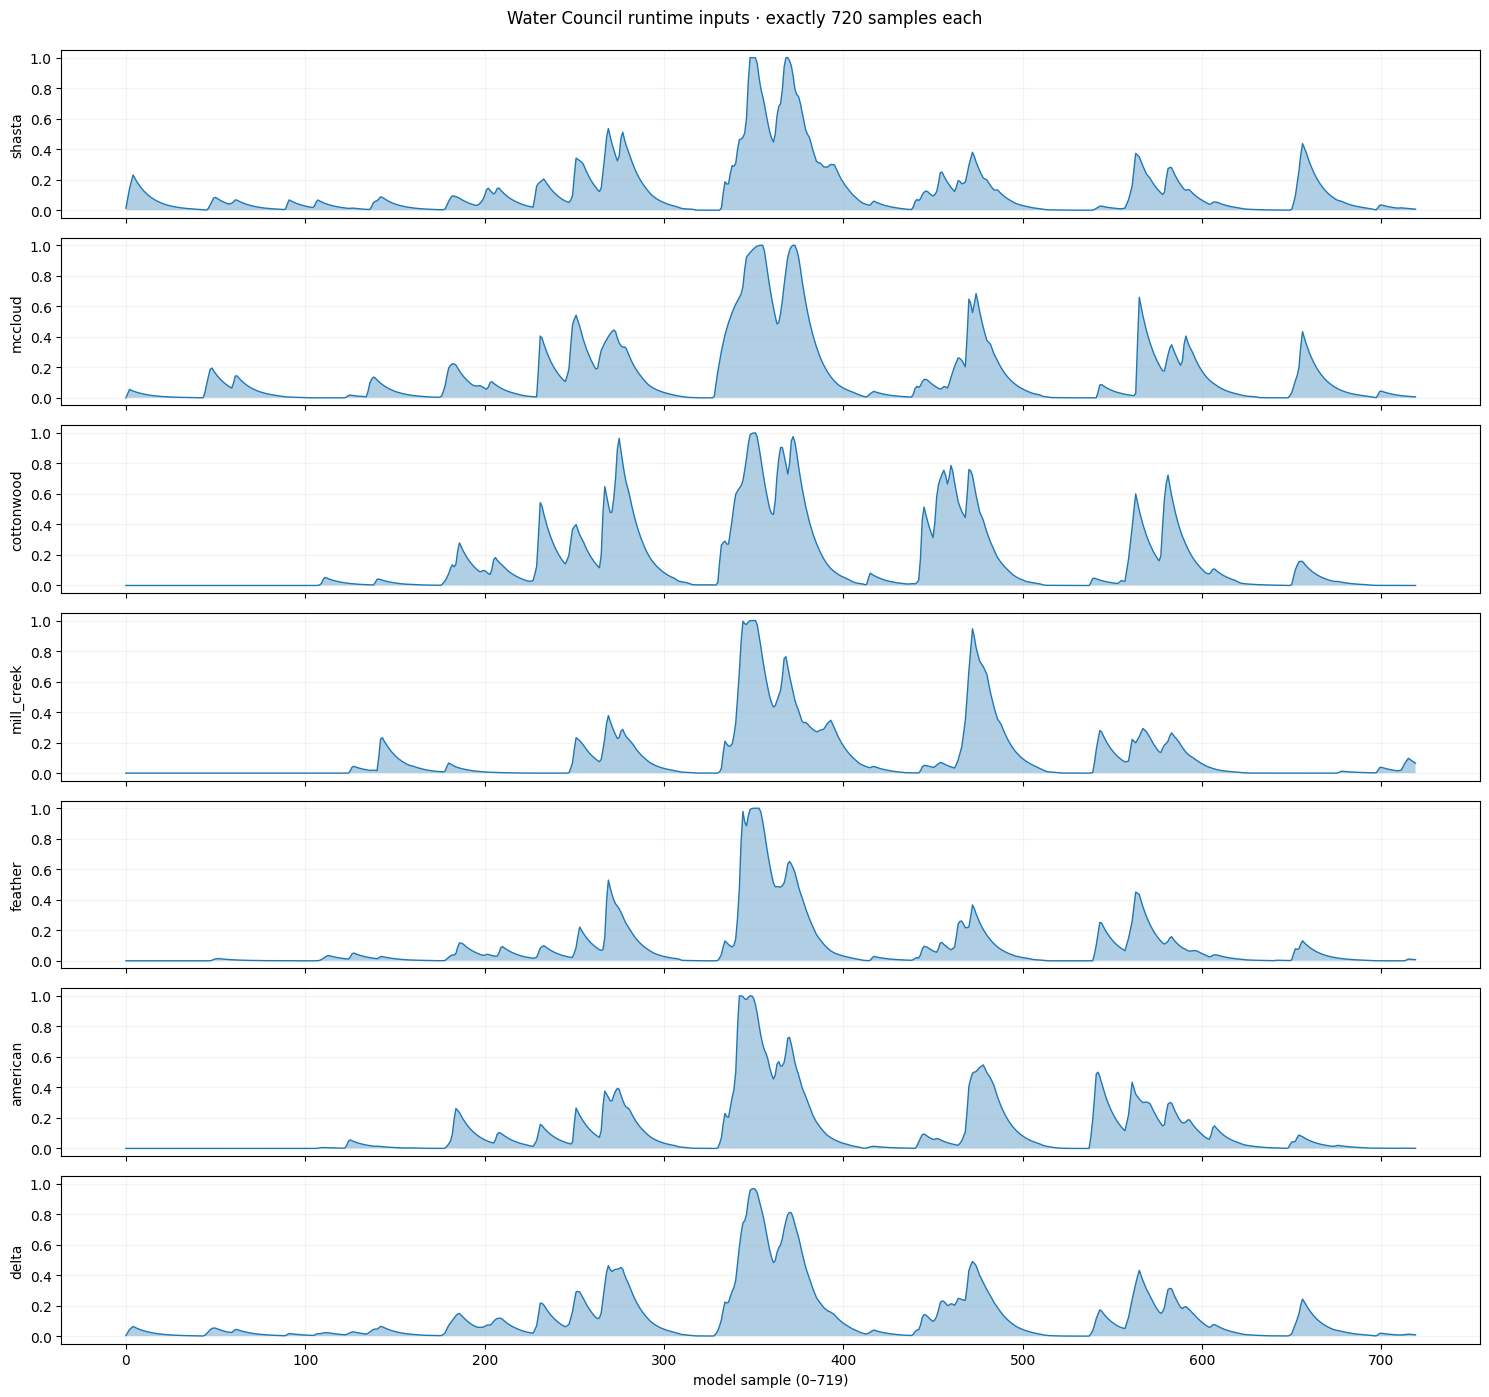

In [5]:
fig, axes = plt.subplots(7, 1, figsize=(15, 14), sharex=True, sharey=True)
for axis, (stage_id, group) in zip(axes, sampled.groupby('stage_id', sort=False)):
    axis.fill_between(group['frame'], group['norm'], alpha=0.35)
    axis.plot(group['frame'], group['norm'], linewidth=1.0)
    axis.set_ylabel(stage_id)
    axis.grid(alpha=0.15)
axes[-1].set_xlabel('model sample (0–719)')
fig.suptitle('Water Council runtime inputs · exactly 720 samples each', y=0.995)
plt.tight_layout()
plt.show()

In [6]:
counts = sampled.groupby('stage_id').size()
assert counts.eq(TARGET_SAMPLE_COUNT).all()
assert sampled['norm'].between(0.0, 1.0).all()
assert abs(sum(DELTA_WEIGHTS.values()) - 1.0) < 1e-12
display(counts.rename('sample_count').to_frame())
print('PASS: seven bounded series, 720 samples per stage')

,sample_count
stage_id,
american,720
cottonwood,720
delta,720
feather,720
mccloud,720
mill_creek,720
shasta,720


PASS: seven bounded series, 720 samples per stage
